# Ambiguity and Discrepancy

In [1]:
#%%
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import pandas as pd
import numpy as np
from functools import partial
from pathlib import Path
import logging

from monoculture.analysis.setup import ACS_TASKS, TABLESHIFT_TASKS
from monoculture.analysis.utils import (
    key_to_model,
    get_size_and_it,
)

from monoculture.analysis.utils import load_model_outputs_same_prompt, get_metric, load_task_data

from monoculture.analysis.metrics import get_ambiguity, get_discrepancy

In [16]:
plot_config_file = "./results/.matplotlibrc"
plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))

TASKS = ACS_TASKS + TABLESHIFT_TASKS

# [
#     "ACSIncome",
#     "ACSEmployment",
#     "BRFSS_Blood_Pressure",
# ]  # ACS_TASKS + TABLESHIFT_TASKS
print("tasks", TASKS)

RESULTS_ROOT_DIR = Path("./results/")
results_df_path = RESULTS_ROOT_DIR / "overview_results_by_prompt_style.csv"
FIGURES_ROOT_DIR = RESULTS_ROOT_DIR / "figures/same-prompt/"
FIGURES_PAPER_DIR = RESULTS_ROOT_DIR / "figures/paper/same-prompt/"

data = None

tasks ('ACSIncome', 'ACSEmployment', 'ACSTravelTime', 'ACSPublicCoverage', 'BRFSS_Diabetes', 'BRFSS_Blood_Pressure')


## Load predictions

In [17]:
num_shots = 0
threshold_fitted = 1

df = pd.read_csv(results_df_path)
# restrict to zero-shot and same prompt style
df_same_prompt = df[
    (df["num_shots"] == num_shots)
    & (df["prompt_format"] == "bullet")
    & (df["prompt_connector"] == "is")
    & (df["prompt_granularity"] == "original")
    & (df["prompt_feature_order"] == "default")
    & (df["threshold_fitted"] == threshold_fitted)
]
df_same_prompt.head()

,task,model,is_inst,threshold_fitted,threshold,accuracy,bench_hash,num_shots,prompt_format,prompt_connector,prompt_granularity,prompt_feature_order,eval_results_path,predictions_path
1,ACSIncome,meta-llama--Meta-Llama-3.2-1B-Instruct,1,1,0.776744,0.680409,3019759728,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...
2,ACSIncome,allenai--OLMo-2-1124-7B-Instruct,1,1,0.904552,0.727768,3118177042,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-allenai--O...,results/folktexts/0-bullet-is/model-allenai--O...
4,ACSIncome,google--gemma-2-27b,0,1,0.438475,0.510381,3621160589,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-google--ge...,results/folktexts/0-bullet-is/model-google--ge...
6,ACSIncome,google--gemma-2-27b-it,1,1,0.867235,0.659718,1712994131,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-google--ge...,results/folktexts/0-bullet-is/model-google--ge...
9,ACSIncome,meta-llama--Meta-Llama-3-70B,0,1,0.532134,0.763641,4121241683,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...


In [18]:
print(df_same_prompt.shape)
try:
    assert set(TASKS).issubset(
        set(df_same_prompt["task"].unique())
    ), f"Results for all tasks to be analysed have to be available, available are: {list(df_same_prompt['task'].unique())} "
except AssertionError:
    logging.warning("Reduced TASKS to available tasks.")
    TASKS = list(df_same_prompt["task"].unique())
TASKS

(288, 14)


('ACSIncome',
 'ACSEmployment',
 'ACSTravelTime',
 'ACSPublicCoverage',
 'BRFSS_Diabetes',
 'BRFSS_Blood_Pressure')

In [19]:
risk_scores = load_model_outputs_same_prompt(
    df_same_prompt, tasks=TASKS, return_risk_scores=True
)
predictions_all = load_model_outputs_same_prompt(
    df_same_prompt, tasks=TASKS, return_risk_scores=False
)

metrics = [
    "n_samples",
    "accuracy",
    "fpr",
    "ppr",
    "num_pred_negatives",
    "num_pred_positives",
    "balanced_accuracy",
]
for metric in metrics:
    df_same_prompt[metric] = (
        df_same_prompt["eval_results_path"]
        .apply(partial(get_metric, metric=metric))
        .copy()
    )

evals_per_task_all = {}  # [task][metric][model]
for task in TASKS:
    df_task = df_same_prompt[df_same_prompt["task"] == task]
    evals_per_task_all[task] = {
        metric: {model: val for model, val in zip(df_task["model"], df_task[metric])}
        for metric in metrics
    }

/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_19576/1532195901.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_same_prompt[metric] = (
/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_19576/1532195901.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_same_prompt[metric] = (
/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_19576/1532195901.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

## Muliplicity measures for all models better const

In [20]:
restrict_to_better_const = True
restrict_to_positive_label = True

predictions_better_const = predictions_all.copy()

if not data:
    logging.warning("Load task data")
    data = load_task_data(TASKS, Path("./data"))

for task in TASKS:
    df_task = df_same_prompt[df_same_prompt["task"] == task]
    y_true = data[task][1]

    if restrict_to_better_const:
        const_acc = max((y_true == 1).sum(), (y_true == 0).sum()) / y_true.shape[0]
        models_better_const = sorted(
            df_task["model"][df_task["accuracy"] > const_acc].to_list(),
            key=get_size_and_it,
        )
        predictions_better_const[task] = predictions_better_const[task].filter(items=models_better_const)

    if restrict_to_positive_label:
        filter_idx = y_true[y_true == int(restrict_to_positive_label)].index
        predictions_better_const[task] = predictions_better_const[task].loc[filter_idx]
    print(task, predictions_better_const[task].shape)

evals_per_task = {
    task: {
        metric: {
            model: evals_per_task_all[task][metric][model]
            for model in predictions_better_const[task].columns
        }
        for metric in evals_per_task_all[task].keys()
    }
    for task in evals_per_task_all.keys()
}

ACSIncome (61233, 40)
ACSEmployment (146740, 42)
ACSTravelTime (64285, 19)
ACSPublicCoverage (33971, 12)
BRFSS_Diabetes (19119, 0)
BRFSS_Blood_Pressure (44586, 36)


In [42]:
latex_version = True
if latex_version: 
    print(f"{'task':20}& M &{'ambiguity':14}&{'discrepancy':20}" )
    for task in TASKS:    
        print(f"{task:20}&{predictions_better_const[task].shape[1]}& {get_ambiguity(predictions=predictions_better_const[task]):.3f}&{get_discrepancy(predictions=predictions_better_const[task]):.3f}\\" )
else: 
    print(f"{'task':20} \tM\t {'ambiguity':14} {'discrepancy':20}" )
    for task in TASKS:    
        print(f"{task:20} \t{predictions_better_const[task].shape[1]}\t {get_ambiguity(predictions=predictions_better_const[task]):.4f}\t\t{get_discrepancy(predictions=predictions_better_const[task]):.4f}" )

task                & M &ambiguity     &discrepancy         
ACSIncome           &40& 0.702&0.370\
ACSEmployment       &42& 0.877&0.665\
ACSTravelTime       &19& 0.818&0.408\
ACSPublicCoverage   &12& 0.769&0.537\
BRFSS_Diabetes      &0& 0.000&0.000\
BRFSS_Blood_Pressure&36& 0.956&0.562\


## Restrict analysis to models based on performance or true labels?

In [22]:
restrict_to_better_const = True
restrict_to_top_eps = False
restrict_to_topk = False
topk = 10
eps = 0.02
restrict_to_positive_label = True
restrict_to_negative_label = False
assert not (
    restrict_to_positive_label & restrict_to_negative_label
), "Choose one or none."

predictions = predictions_all.copy()

if any(
    [restrict_to_better_const, restrict_to_positive_label, restrict_to_negative_label]
):
    if not data:
        logging.warning("Load task data")
        data = load_task_data(TASKS, Path("./data"))

    for task in TASKS:
        df_task = df_same_prompt[df_same_prompt["task"] == task]
        y_true = data[task][1]

        if restrict_to_better_const:
            const_acc = max((y_true == 1).sum(), (y_true == 0).sum()) / y_true.shape[0]
            models_better_const = sorted(
                df_task["model"][df_task["accuracy"] > const_acc].to_list(),
                key=get_size_and_it,
            )
            predictions[task] = predictions[task].filter(items=models_better_const)

        if restrict_to_negative_label or restrict_to_positive_label:
            filter_idx = y_true[y_true == int(restrict_to_positive_label)].index
            predictions[task] = predictions[task].loc[filter_idx]
        print(task, predictions[task].shape)

if restrict_to_topk or restrict_to_top_eps:
    assert not (restrict_to_top_eps & restrict_to_topk)
    for task in TASKS:
        df_task_sorted_by_acc = df_same_prompt[
            df_same_prompt["task"] == task
        ].sort_values(by="accuracy", ascending=False)
        if restrict_to_topk:
            models = sorted(
                df_task_sorted_by_acc.iloc[:topk]["model"].to_list(),
                key=get_size_and_it,
            )
            predictions[task] = predictions[task].filter(items=models)
        if restrict_to_top_eps:
            top_acc = df_task_sorted_by_acc.iloc[0]["accuracy"].item()
            models = sorted(
                df_task_sorted_by_acc[
                    df_task_sorted_by_acc["accuracy"] > top_acc - eps
                ]["model"].to_list(),
                key=get_size_and_it,
            )
            predictions[task] = predictions[task].filter(items=models)
        print(task, predictions[task].shape)

evals_per_task = {
    task: {
        metric: {
            model: evals_per_task_all[task][metric][model]
            for model in predictions[task].columns
        }
        for metric in evals_per_task_all[task].keys()
    }
    for task in evals_per_task_all.keys()
}

ACSIncome (61233, 40)
ACSEmployment (146740, 42)
ACSTravelTime (64285, 19)
ACSPublicCoverage (33971, 12)
BRFSS_Diabetes (19119, 0)
BRFSS_Blood_Pressure (44586, 36)


## Muliplicity measures for different values of $\epsilon$
*inspired by Marx et al. Fig 3*

In [31]:
multiplicity_measures = {}

for task in TASKS:
    df_task_sorted_by_acc = df_same_prompt[df_same_prompt["task"] == task].sort_values(
        by="accuracy", ascending=False
    )
    top_acc = df_task_sorted_by_acc.iloc[0]["accuracy"].item()
    multiplicity_measures[task] = {}

    num_models = []
    ambiguities = []
    discrepancies = []

    top_acc = df_task_sorted_by_acc.iloc[0]["accuracy"].item()
    y_true = data[task][1]
    const_acc = max((y_true == 1).sum(), (y_true == 0).sum()) / y_true.shape[0]
    print(f"{task} top: {top_acc:.4f} const: {const_acc:.4f} diff: {top_acc - const_acc}")
    epsilon = np.arange(0.0, max(top_acc - const_acc, 0.05)+0.005, 0.005)
    for eps in epsilon:
        models = sorted(
            df_task_sorted_by_acc[df_task_sorted_by_acc["accuracy"] > top_acc - eps][
                "model"
            ].to_list(),
            key=get_size_and_it,
        )
        filtered_df = predictions[task].filter(items=models)
        num_models.append(filtered_df.shape[1])
        ambiguities.append(get_ambiguity(filtered_df))
        discrepancies.append(get_discrepancy(filtered_df))

    if predictions[task].shape[1] > 0:
        multiplicity_measures[task] = {
            "eps": epsilon,
            "num_models": num_models,
            "ambiguity": np.array(ambiguities),
            "discrepancy": np.array(discrepancies),
        }

ACSIncome top: 0.7885 const: 0.6321 diff: 0.1563592670471613
ACSEmployment top: 0.7998 const: 0.5466 diff: 0.2532546792290744
ACSTravelTime top: 0.6455 const: 0.5617 diff: 0.0837895885180513
ACSPublicCoverage top: 0.7278 const: 0.7016 diff: 0.026258686275026588
BRFSS_Diabetes top: 0.7683 const: 0.8676 diff: -0.09933664778628704
BRFSS_Blood_Pressure top: 0.6265 const: 0.5265 diff: 0.09995748500165336


multiplicity-0-shot_tresh_fitted_better_const_pos_instances.png


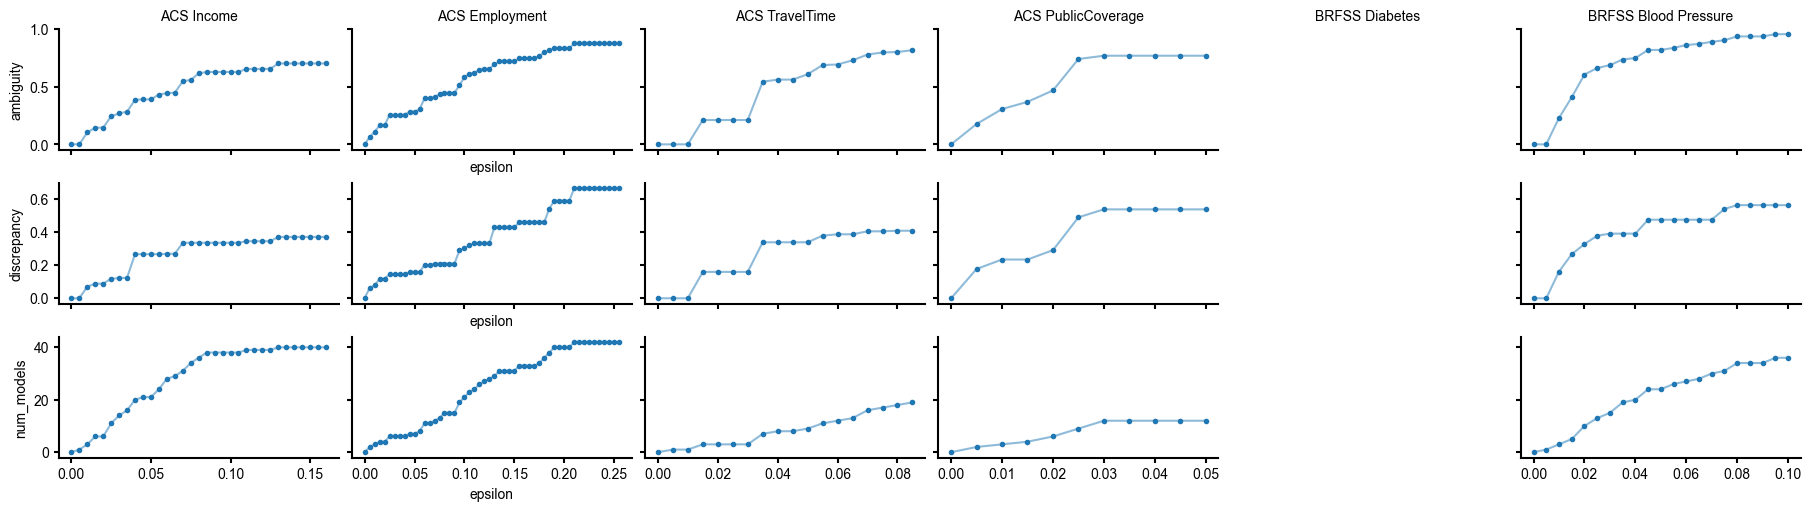

In [37]:
tasks_to_plot = TASKS  # ['ACSIncome', 'ACSEmployment', 'BRFSS_Blood_Pressure']

fig, axs = plt.subplots(
    3, len(tasks_to_plot), figsize=(3 * len(tasks_to_plot), 5), constrained_layout=True, sharex='col', sharey='row'
)

sort_by = None
for m, measure in enumerate(["ambiguity", "discrepancy", "num_models"]):
    for t, task in enumerate(tasks_to_plot):
        if len(multiplicity_measures[task])>0:
            axs[m, t].plot(
                multiplicity_measures[task]["eps"],
                multiplicity_measures[task][measure],
                color='C0', 
                alpha = 0.5
            )
            axs[m, t].scatter(
                multiplicity_measures[task]["eps"],
                multiplicity_measures[task][measure],
                color='C0'
            )
        else:
            axs[m, t].set_axis_off()
        axs[0,t].set_title(task.replace('ACS', 'ACS ').replace('_', ' '))
    # axs[0].legend()
    axs[m, 0].set_ylabel(measure)
    axs[m, 1].set_xlabel("epsilon")
    # axs[m,t].set_xticks(epsilon[::4])

file_name = "".join(
    [
        f"multiplicity-{num_shots}-shot",
        "_tresh_fitted" if threshold_fitted == 1 else "",
        "_better_const" if restrict_to_better_const else "",
        "_pos_instances" if restrict_to_positive_label else "",
        "_neg_instances" if restrict_to_negative_label else "",
        ".png",
    ]
)
plt.savefig(FIGURES_ROOT_DIR/file_name)
plt.savefig(FIGURES_PAPER_DIR/file_name)
print(file_name)


plt.show()